In [1]:
import scarf

scarf.fetch_dataset('tenx_5K_pbmc_rnaseq', save_path='scarf_datasets')
reader = scarf.CrH5Reader('scarf_datasets/tenx_5K_pbmc_rnaseq/data.h5')
scarf.CrToZarr(reader, zarr_loc='scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr').dump(batch_size=1000)

  0%|                                                                                                         …

In [2]:
ds = scarf.DataStore('scarf_datasets/tenx_5K_pbmc_rnaseq/data.zarr', nthreads=4, min_features_per_cell=10)
ds.filter_cells(attrs=['RNA_nCounts', 'RNA_nFeatures'], highs=[15000, 4000], lows=[1000, 500])

(RNA) Computing nCells and dropOuts:   0%|                                                                    …

(RNA) Computing nCounts:   0%|                                                                                …

(RNA) Computing nFeatures:   0%|                                                                              …

(RNA) Computing RNA_percentMito:   0%|                                                                        …

(RNA) Computing RNA_percentRibo:   0%|                                                                        …

INFO: 597 cells flagged for filtering out using attribute RNA_nCounts


INFO: 461 cells flagged for filtering out using attribute RNA_nFeatures


INFO: Calculating summary statistics


(RNA) Computing feature stats:   0%|                                                                          …

INFO: Calculating HVGs


INFO: 500 genes marked as HVGs


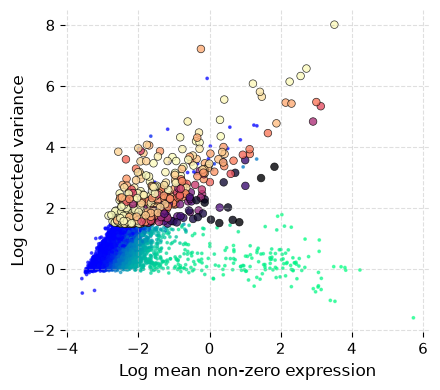

INFO: make_graph step 1/7: normalize expression matrix (computing)


Writing data to normed__I__hvgs/data:   0%|                                                                   …

INFO: make_graph step 1/7: normalize expression matrix finished in 1.2s (computing)


INFO: make_graph step 2/7: normalization statistics (computing)


Calculating mean and std. dev. of norm. data:   0%|                                                           …

...

INFO: ANN recall: 99.95%


INFO: make_graph step 7/7: finalize graph metadata (computing)


INFO: make_graph step 7/7: finalize graph metadata finished in 0.0s (computing)


INFO: make_graph finished in 9.7s (7/7 steps, 9.7s in logged steps)


Training UMAP:   0%|                                                                                          …

In [3]:
ds.mark_hvgs(min_cells=20, top_n=500)
ds.make_graph(feat_key='hvgs', k=11, dims=15, n_centroids=100)
ds.run_umap(n_epochs=250, spread=5, min_dist=1, parallel=True)
ds.run_leiden_clustering(resolution=0.5)

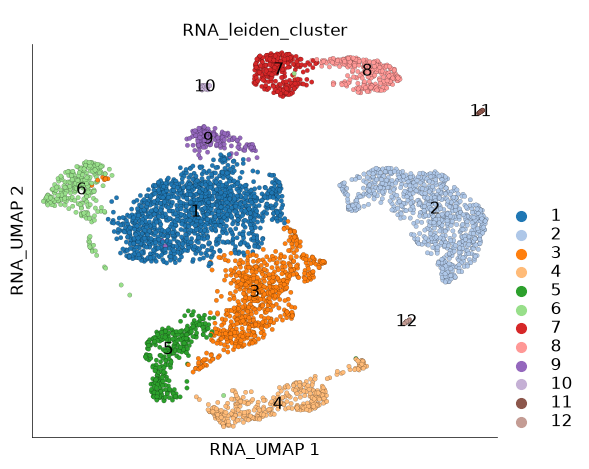

In [4]:
ds.plot_layout(layout_key='RNA_UMAP', color_by='RNA_leiden_cluster')